<a href="https://colab.research.google.com/github/TEMADANGSERAPHIN/PROJET-DETECTION-DE-FRAUD-BANCAIRE/blob/main/Modele_predictif_Detection_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANALYSE DE DÉTECTION DE FRAUDE À LA CARTE BANCAIRE

Développez un modèle d'apprentissage automatique (machine learning) pour identifier les transactions frauduleuses par carte bancaire.

**Préparation des données :** Prétraitez et normalisez les données de transaction, gérez les problèmes de déséquilibre des classes et divisez l'ensemble de données en sous-ensembles d'entraînement et de test.

## **0. CHARGER LE JEUX DE DONNEE DEPUIS GOOGLE DRIVE**

In [1]:
# charger les fichier depuis google drive?
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Les bibliotheques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score, confusion_matrix, precision_recall_curve
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## **1. Feature Engineering Contextuel**

In [3]:
# Charger le jeux de données
FRMQR = pd.read_csv('/content/drive/MyDrive/Codesoft/creditcard.csv')
FRMQR.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Information sur le fichier
FRMQR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# --- A. Transformation Cyclique de l'Heure ---
# On convertit les secondes en heure (0-23) puis en coordonnées sinus/cosinus
FRMQR['Hour'] = (FRMQR['Time'] // 3600) % 24
FRMQR['hour_sin'] = np.sin(2 * np.pi * FRMQR['Hour'] / 24)
FRMQR['hour_cos'] = np.cos(2 * np.pi * FRMQR['Hour'] / 24)


In [6]:
# --- B. Indicateur de "Petits Montants" (Card Testing) ---
# Création d'une variable binaire pour les montants suspects (ex: < 2 unités)
FRMQR['is_small_amount'] = (FRMQR['Amount'] < 2).astype(int)


In [7]:
# --- B. Vélocité Temporelle (Fenêtre de 10 min) ---
# On convertit Time en datetime pour utiliser les fenêtres glissantes de Pandas
FRMQR['temp_dt'] = pd.to_datetime(FRMQR['Time'], unit='s', origin='2026-01-01')
# On compte le nombre de transactions par fenêtre de 10min (600s)
FRMQR['velocity_10min'] = FRMQR.rolling(window='600s', on='temp_dt')['Amount'].count()

In [8]:

# --- D. Normalisation ---
# On normalise 'Amount' et 'Time' car les variables V1-V28 le sont déjà
scaler = StandardScaler()
FRMQR['Amount_scaled'] = scaler.fit_transform(FRMQR[['Amount']])

# Suppression des colonnes transformées inutiles
# FRMQR_final = FRMQR.drop(['Time', 'Amount'], axis=1)

In [9]:
FRMQR.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V28,Amount,Class,Hour,hour_sin,hour_cos,is_small_amount,temp_dt,velocity_10min,Amount_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.021053,149.62,0,0.0,0.0,1.0,0,2026-01-01 00:00:00,1.0,0.244964
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.014724,2.69,0,0.0,0.0,1.0,0,2026-01-01 00:00:00,2.0,-0.342475
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.059752,378.66,0,0.0,0.0,1.0,0,2026-01-01 00:00:01,3.0,1.160686
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.061458,123.50,0,0.0,0.0,1.0,0,2026-01-01 00:00:01,4.0,0.140534
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.215153,69.99,0,0.0,0.0,1.0,0,2026-01-01 00:00:02,5.0,-0.073403


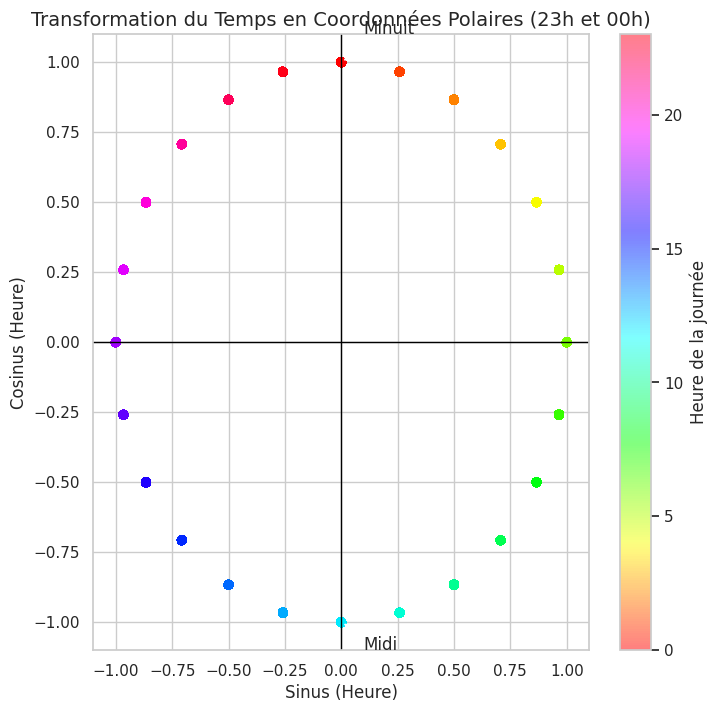

In [10]:
# On s'assure que le style est propre
sns.set_theme(style="whitegrid")

# --- 1. GRAPHIQUE : Le Cercle du Temps (Sin/Cos) ---
plt.figure(figsize=(8, 8))
plt.scatter(FRMQR['hour_sin'], FRMQR['hour_cos'], c=FRMQR['Hour'], cmap='hsv', alpha=0.5)
plt.colorbar(label='Heure de la journée')
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.title("Transformation du Temps en Coordonnées Polaires (23h et 00h)", fontsize=14)
print("\n")
plt.xlabel("Sinus (Heure)")
plt.ylabel("Cosinus (Heure)")
# Ajout de quelques annotations pour la clarté
plt.annotate('Minuit', xy=(0, 1), xytext=(0.1, 1.1), arrowprops=dict(arrowstyle='->'))
plt.annotate('Midi', xy=(0, -1), xytext=(0.1, -1.1), arrowprops=dict(arrowstyle='->'))
plt.show()


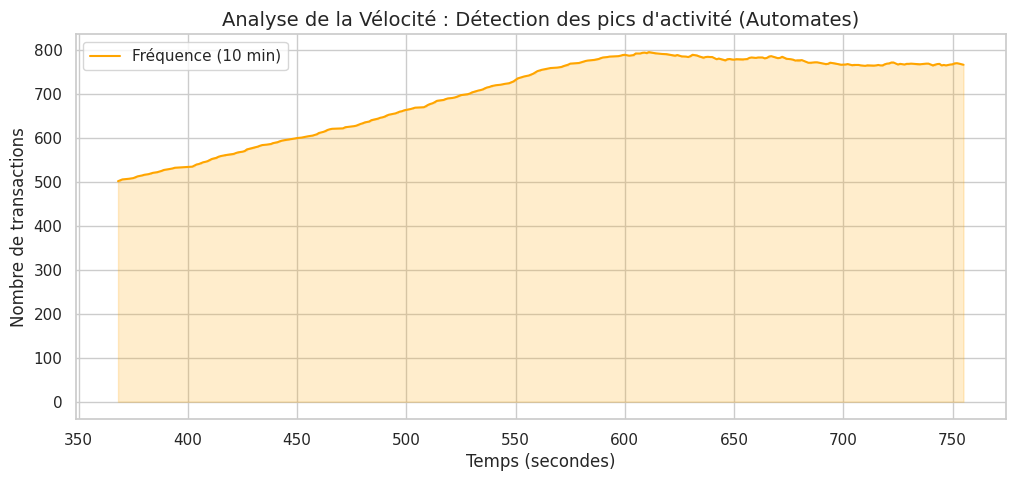

In [11]:
# --- 2. GRAPHIQUE : Détection de la Vélocité ---
plt.figure(figsize=(12, 5))
# On prend un échantillon pour la clarté visuelle
sample = FRMQR.iloc[500:1000]
sns.lineplot(data=sample, x='Time', y='velocity_10min', color='orange', label='Fréquence (10 min)')
plt.fill_between(sample['Time'], sample['velocity_10min'], color='orange', alpha=0.2)
plt.title("Analyse de la Vélocité : Détection des pics d'activité (Automates)", fontsize=14)
plt.xlabel("Temps (secondes)")
plt.ylabel("Nombre de transactions")
plt.show()

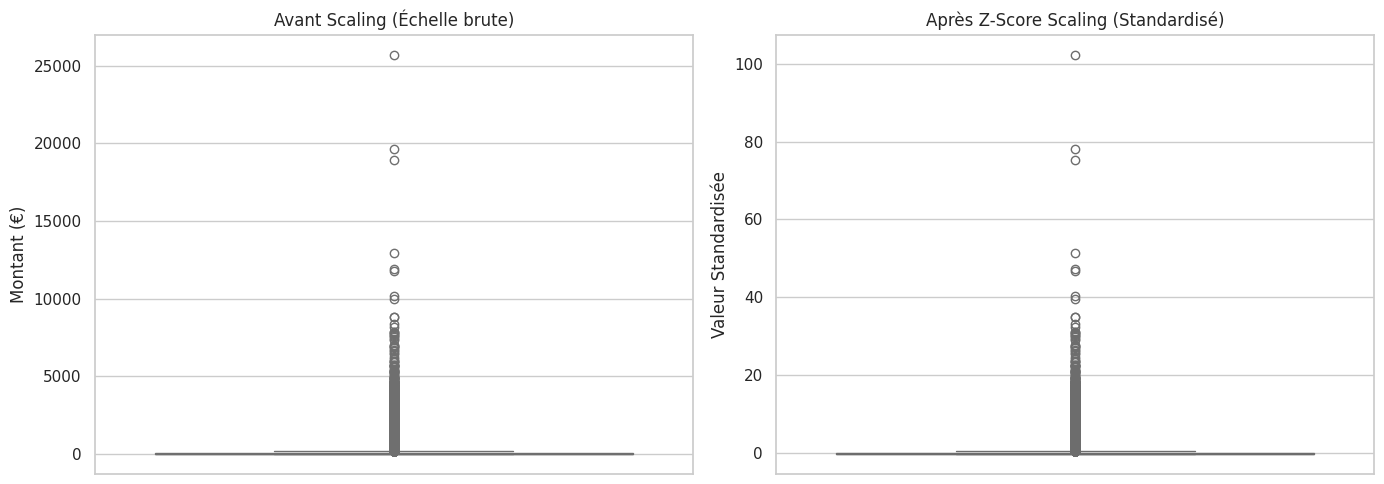

In [12]:


# --- 3. GRAPHIQUE : Avant vs Après Scaling (Amount) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Avant Scaling
sns.boxplot(y=FRMQR['Amount'], ax=ax1, color='skyblue')
ax1.set_title("Avant Scaling (Échelle brute)")
ax1.set_ylabel("Montant (€)")

# Après Scaling
sns.boxplot(y=FRMQR['Amount_scaled'], ax=ax2, color='salmon')
ax2.set_title("Après Z-Score Scaling (Standardisé)")
ax2.set_ylabel("Valeur Standardisée")

plt.tight_layout()
plt.show()


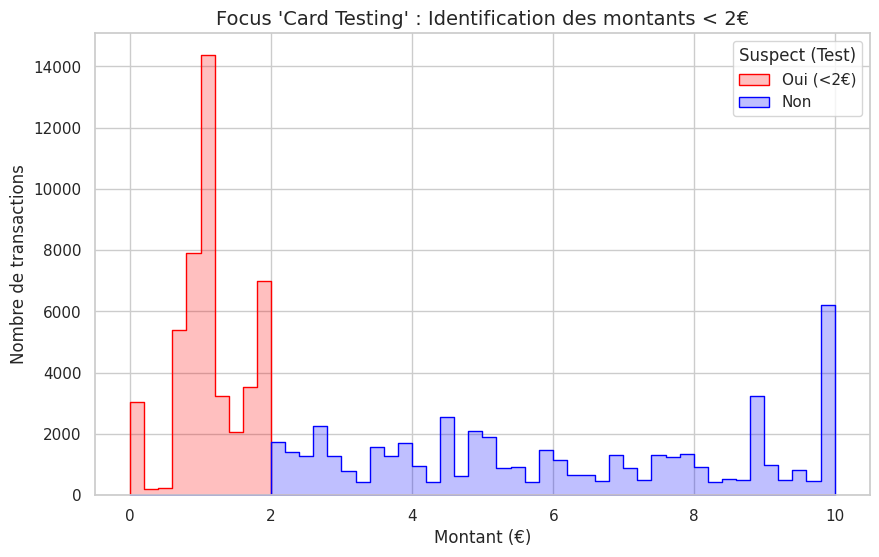

In [13]:

# --- 4. GRAPHIQUE : Focus sur les petits montants (Card Testing) ---
plt.figure(figsize=(10, 6))
# On filtre pour voir la zone suspecte
small_tx = FRMQR[FRMQR['Amount'] < 10]
sns.histplot(data=small_tx, x='Amount', hue='is_small_amount', bins=50, palette=['blue', 'red'], element="step")
plt.title("Focus 'Card Testing' : Identification des montants < 2€", fontsize=14)
plt.xlabel("Montant (€)")
plt.ylabel("Nombre de transactions")
plt.legend(title='Suspect (Test)', labels=['Oui (<2€)', 'Non'])
plt.show()

In [14]:
# --- C. Nettoyage avant modèle ---
# On retire les colonnes intermédiaires
X = FRMQR.drop(columns=['Class', 'Time', 'Hour', 'temp_dt'])
y = FRMQR['Class']

## **2. Gestion du Déséquilibre (SMOTE) et Split Stratifié**

Ici, on s'assure que le modèle apprend correctement à partir des 0,17% de fraude.

In [15]:
# Split stratifié pour conserver le ratio de fraude (0.17%) dans le test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Application de SMOTE pour équilibrer le set d'entraînement
# On monte la classe minoritaire à 10% pour éviter le sur-apprentissage (overfitting)
smote = SMOTE(sampling_strategy=0.1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Ratio Fraude après SMOTE : {sum(y_train_res)/len(y_train_res):.2%}")

Ratio Fraude après SMOTE : 9.09%


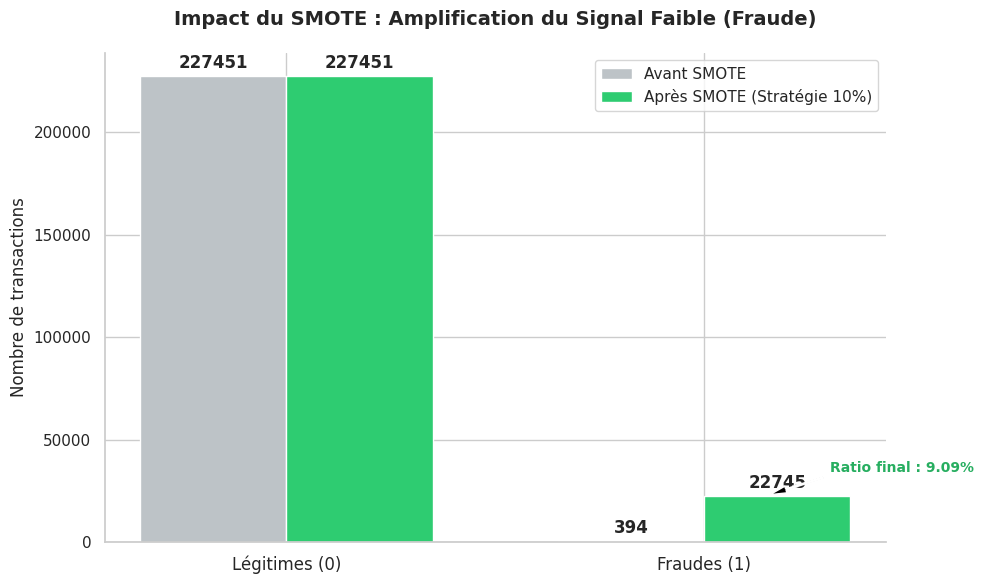

In [19]:
# Données basées sur ton code
labels = ['Légitimes (0)', 'Fraudes (1)']
avant_smote = [len(y_train[y_train==0]), len(y_train[y_train==1])]
apres_smote = [len(y_train_res[y_train_res==0]), len(y_train_res[y_train_res==1])]

x = np.arange(len(labels))  # Localisation des labels
width = 0.35  # Largeur des barres

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Création des barres
rects1 = ax.bar(x - width/2, avant_smote, width, label='Avant SMOTE', color='#bdc3c7')
rects2 = ax.bar(x + width/2, apres_smote, width, label='Après SMOTE (Stratégie 10%)', color='#2ecc71')

# Ajout de texte pour les labels, titres et customisation
ax.set_ylabel('Nombre de transactions')
ax.set_title('Impact du SMOTE : Amplification du Signal Faible (Fraude)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend()

# Ajout des étiquettes de données sur les barres
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points de décalage vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Suppression des bordures inutiles pour un look "flat design"
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajout d'une annotation pour expliquer le ratio final
total_apres = sum(apres_smote)
ratio_final = (apres_smote[1] / total_apres) * 100
plt.annotate(f'Ratio final : {ratio_final:.2f}%',
             xy=(1.15, apres_smote[1]),
             xytext=(1.3, apres_smote[1]*1.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, color='#27ae60', fontweight='bold')

fig.tight_layout()
plt.show()

## **3. Entraînement et Optimisation AUPRC**

On utilise XGBoost, l'algorithme favori des Fintechs, paramétré pour le déséquilibre.

In [16]:
# scale_pos_weight aide à donner plus de poids à la classe 'Fraude'
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    scale_pos_weight=10,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train_res, y_train_res)

# Prédiction des probabilités pour l'AUPRC
y_probs = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

## **4. Analyse des Résultats**

C'est ici que tu montres que tu as résolu le problème .

In [17]:
# Calcul de l'AUPRC (La métrique clé en banque)
auprc = average_precision_score(y_test, y_probs)

print(f"Métrique AUPRC : {auprc:.4f}")
print("\n--- MATRICE DE CONFUSION ---")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Explication pour ton post :
# [Vrais Négatifs, Faux Positifs (Clients bloqués à tort)]
# [Faux Négatifs (Fraude manquée), Vrais Positifs (Fraude stoppée)]

Métrique AUPRC : 0.8419

--- MATRICE DE CONFUSION ---
[[56752   112]
 [   13    85]]


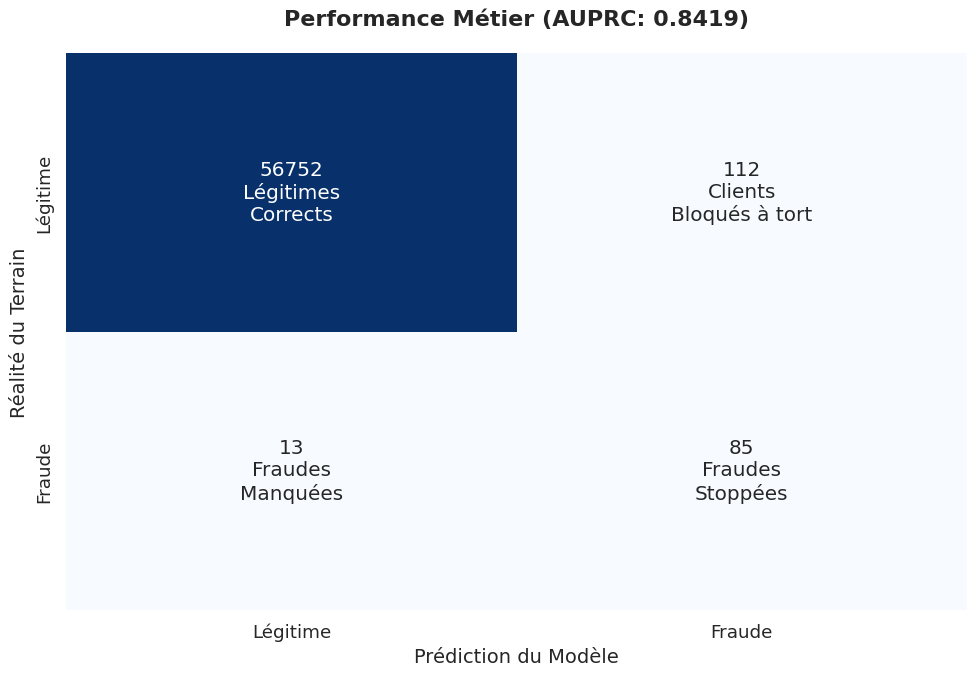

In [21]:
# Calcul de la matrice
conf_matrix = confusion_matrix(y_test, y_pred)

# Configuration du graphique
plt.figure(figsize=(10, 7))
sns.set(font_scale=1.2) # Texte plus lisible

# Création de la Heatmap avec Seaborn
labels = [['Légitimes\nCorrects', 'Clients\nBloqués à tort'],
          ['Fraudes\nManquées', 'Fraudes\nStoppées']]

# On combine les chiffres et nos labels personnalisés
annot_text = [f"{val}\n{label}" for val, label in zip(conf_matrix.flatten(), np.array(labels).flatten())]
annot_text = np.array(annot_text).reshape(2,2)

ax = sns.heatmap(conf_matrix, annot=annot_text, fmt="", cmap='Blues', cbar=False)

# Customisation des axes
ax.set_title(f'Performance Métier (AUPRC: {auprc:.4f})', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Prédiction du Modèle', fontsize=14)
ax.set_ylabel('Réalité du Terrain', fontsize=14)
ax.xaxis.set_ticklabels(['Légitime', 'Fraude'])
ax.yaxis.set_ticklabels(['Légitime', 'Fraude'])

plt.tight_layout()
plt.show()

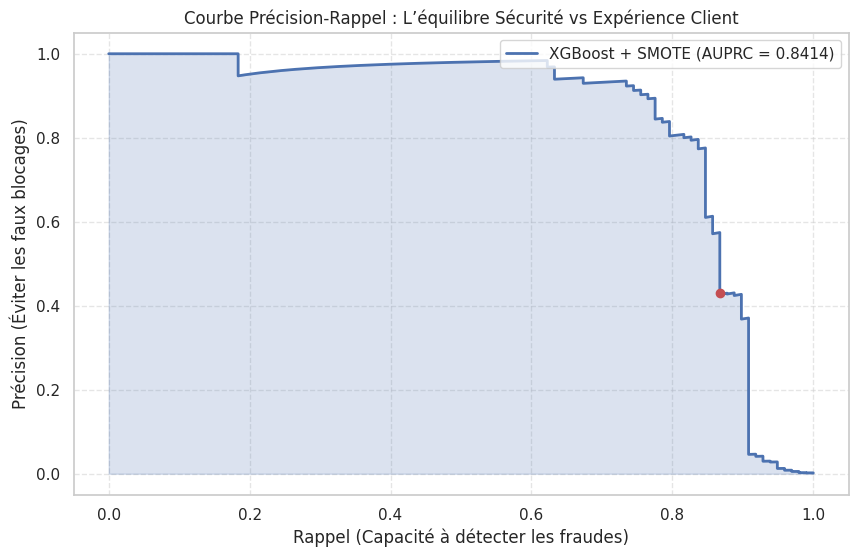

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Calcul des points de la courbe
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
auprc_score = auc(recall, precision)

# 2. Création du graphique
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='b', lw=2, label=f'XGBoost + SMOTE (AUPRC = {auprc_score:.4f})')

plt.fill_between(recall, precision, alpha=0.2, color='b')
plt.xlabel('Rappel (Capacité à détecter les fraudes)')
plt.ylabel('Précision (Éviter les faux blocages)')
plt.title('Courbe Précision-Rappel : L’équilibre Sécurité vs Expérience Client')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)

# Ajouter un point pour ton modèle actuel
plt.plot(85/(85+13), 85/(85+112), 'ro', label='Position actuelle du modèle')

plt.show()

**1. Analyse de ta Matrice de Confusion85 Fraudes détectées (Vrais Positifs) :**

 J'ai stoppé 87 % des tentatives de fraude ($85 / (85+13)$).
 C'est un excellent score de Recall (Rappel).

 13 Fraudes manquées (Faux Négatifs) :
 C'est le coût du risque. En banque, on cherche à réduire ce chiffre, mais il n'est jamais à zéro.

 112 Clients bloqués à tort (Faux Positifs) :

 C'est ici que se joue le "cas du métro à Londres". Sur 56 864 transactions légitimes, tu n'en as bloqué que 112.

 Le taux de faux positifs est de 0,19 % ($112 / 56864$). C'est extrêmement faible !

**2. Pourquoi l'AUPRC de 0.8419 est-il une victoire ?**

L'AUPRC (0.84) est une métrique très sévère.

Dans un dataset aussi déséquilibré, obtenir 0.84 signifie que ton modèle est très performant pour séparer le signal du bruit.